In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

import statsmodels.api as sm
import statsmodels.formula.api as smf

from patsy import dmatrix

In [3]:
#load auto dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/Auto.csv"
Auto = pd.read_csv(url)
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


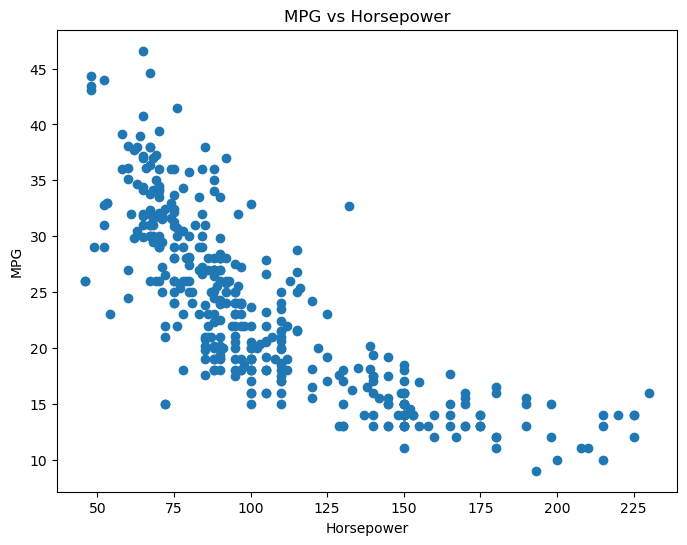

In [5]:
#initial scatterplot
plt.figure(figsize=(8,6))

plt.scatter(Auto["horsepower"], Auto["mpg"])

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("MPG vs Horsepower")

plt.show()

In [6]:
#fit linear regression
X = Auto[["horsepower"]]
y = Auto["mpg"]

linear_model = LinearRegression()
linear_model.fit(X, y)

pred_linear = linear_model.predict(X)

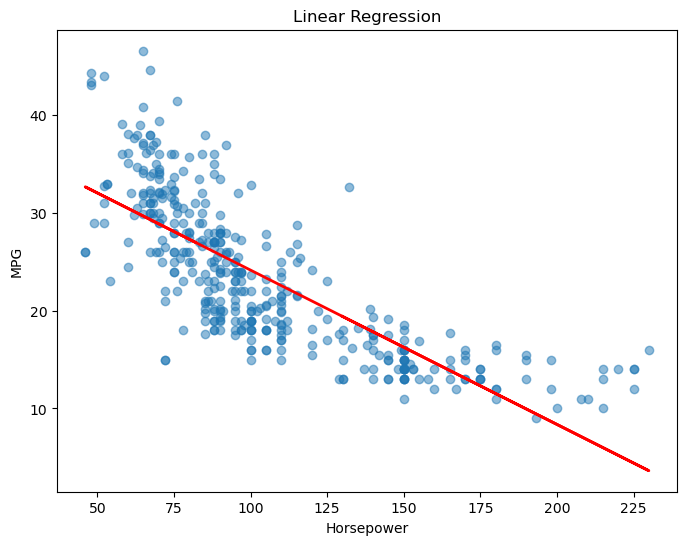

In [7]:
#plot linear model
plt.figure(figsize=(8,6))

plt.scatter(Auto["horsepower"], y, alpha=0.5)

plt.plot(
    Auto["horsepower"],
    pred_linear,
    color="red",
    linewidth=2
)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Linear Regression")

plt.show()

In [8]:
#Polynomial Regression (Degree 2)
poly2_model = make_pipeline(
    PolynomialFeatures(2),
    LinearRegression()
)

poly2_model.fit(X, y)

pred_poly2 = poly2_model.predict(X)

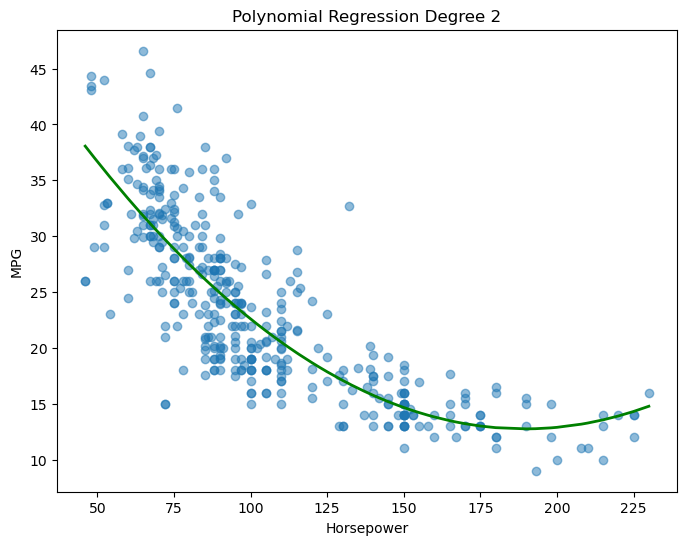

In [9]:
#Plot Polynomial Regression
sorted_idx = Auto["horsepower"].argsort()

plt.figure(figsize=(8,6))

plt.scatter(Auto["horsepower"], y, alpha=0.5)

plt.plot(
    Auto["horsepower"].iloc[sorted_idx],
    pred_poly2[sorted_idx],
    color="green",
    linewidth=2
)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial Regression Degree 2")

plt.show()

In [10]:
#Polynomial Regression (Degree 3)
poly3_model = make_pipeline(
    PolynomialFeatures(3),
    LinearRegression()
)

poly3_model.fit(X, y)

pred_poly3 = poly3_model.predict(X)

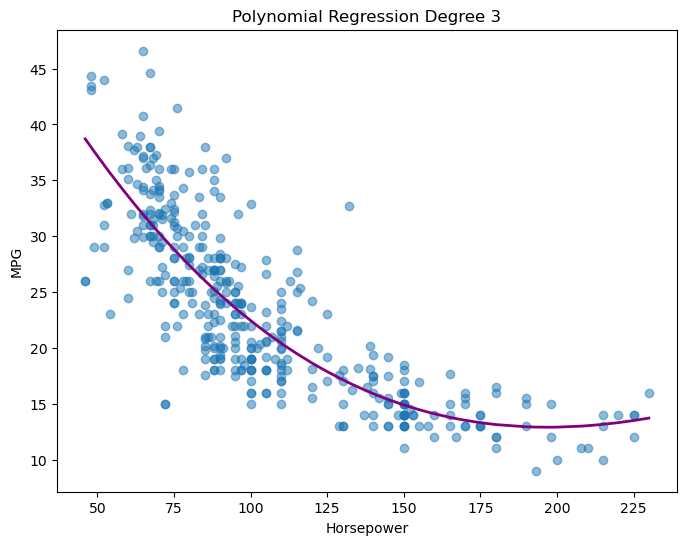

In [11]:
#Plot Degree 3
plt.figure(figsize=(8,6))

plt.scatter(Auto["horsepower"], y, alpha=0.5)

plt.plot(
    Auto["horsepower"].iloc[sorted_idx],
    pred_poly3[sorted_idx],
    color="purple",
    linewidth=2
)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial Regression Degree 3")

plt.show()

In [12]:
#Fit a Step Function
Auto["hp_cut"] = pd.cut(
    Auto["horsepower"],
    bins=4
)

step_model = smf.ols(
    "mpg ~ C(hp_cut)",
    data=Auto
).fit()

print(step_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.593
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     188.1
Date:                Thu, 14 May 2026   Prob (F-statistic):           2.69e-75
Time:                        08:46:12   Log-Likelihood:                -1185.2
No. Observations:                 392   AIC:                             2378.
Df Residuals:                     388   BIC:                             2394.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

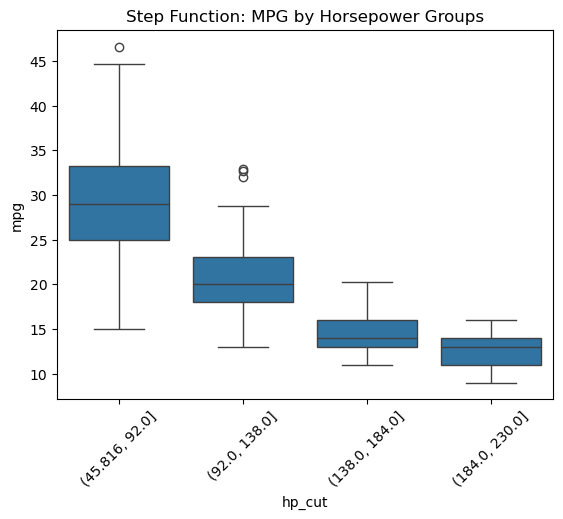

In [13]:
#Plot Step Function
sns.boxplot(
    x="hp_cut",
    y="mpg",
    data=Auto
)

plt.xticks(rotation=45)

plt.title("Step Function: MPG by Horsepower Groups")

plt.show()

In [14]:
#Regression Splines
transformed_x = dmatrix(
    "bs(train, df=6, degree=3)",
    {"train": Auto["horsepower"]},
    return_type='dataframe'
)

spline_model = sm.GLM(
    y,
    transformed_x
).fit()

pred_spline = spline_model.predict(transformed_x)

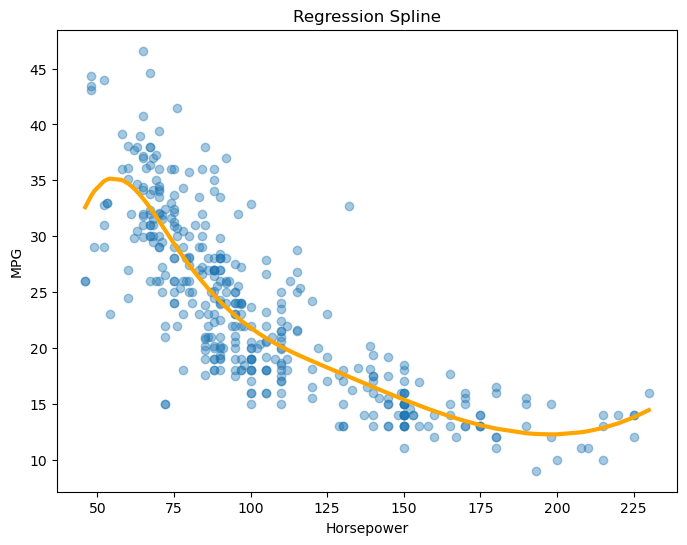

In [16]:
#Plot Spline Model
plt.figure(figsize=(8,6))

plt.scatter(
    Auto["horsepower"],
    y,
    alpha=0.4
)

plt.plot(
    Auto["horsepower"].iloc[sorted_idx],
    pred_spline.iloc[sorted_idx],
    color="orange",
    linewidth=3
)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Regression Spline")

plt.show()

In [17]:
#Compare Models Using MSE
mse_linear = mean_squared_error(y, pred_linear)
mse_poly2 = mean_squared_error(y, pred_poly2)
mse_poly3 = mean_squared_error(y, pred_poly3)
mse_spline = mean_squared_error(y, pred_spline)

comparison = pd.DataFrame({
    "Model": [
        "Linear",
        "Polynomial Degree 2",
        "Polynomial Degree 3",
        "Spline"
    ],
    "MSE": [
        mse_linear,
        mse_poly2,
        mse_poly3,
        mse_spline
    ]
})

comparison

,Model,MSE
0,Linear,23.943663
1,Polynomial Degree 2,18.984769
2,Polynomial Degree 3,18.944990
3,Spline,18.106431
